### RNN

#### 1.神经网络的记忆力

- 传统神经网络（比如全连接）不能记住过去的信息。但对于语言和音频来说，上下文就是一切  
- RNN在每个时间步进行计算时，不仅接受当前的输入，还会接受来自上一个时刻的信号（隐藏状态）

#### 2.RNN的结构

- 输入层：在每一个时刻t，给模型特征向量
- 隐藏状态：$H_t = \sigma(W_xH_{t-1} + W_hH_t + b_h)$
  - 隐藏状态是将当下输入与过去记忆融合后的结果
  - 激活函数通常使用tanh函数（数值压缩到-1到1之间），防止长序列的梯度爆炸
- 输出层：$O_t = \sigma(W_xH_t + b_o)$。基于当前记忆状态，模型判断这一刻是否出发了目标

#### 3.应用场景
- 短序列预测：如未来几小时的天气温度、湿度变化
- 简单字符级文本生成：基于前几个字符预测下一个字符
- 语音识别的前端特征处理：与HMM结合用于孤立词识别
- 序列标注的baseline：词性标注，上下文长度很短可用

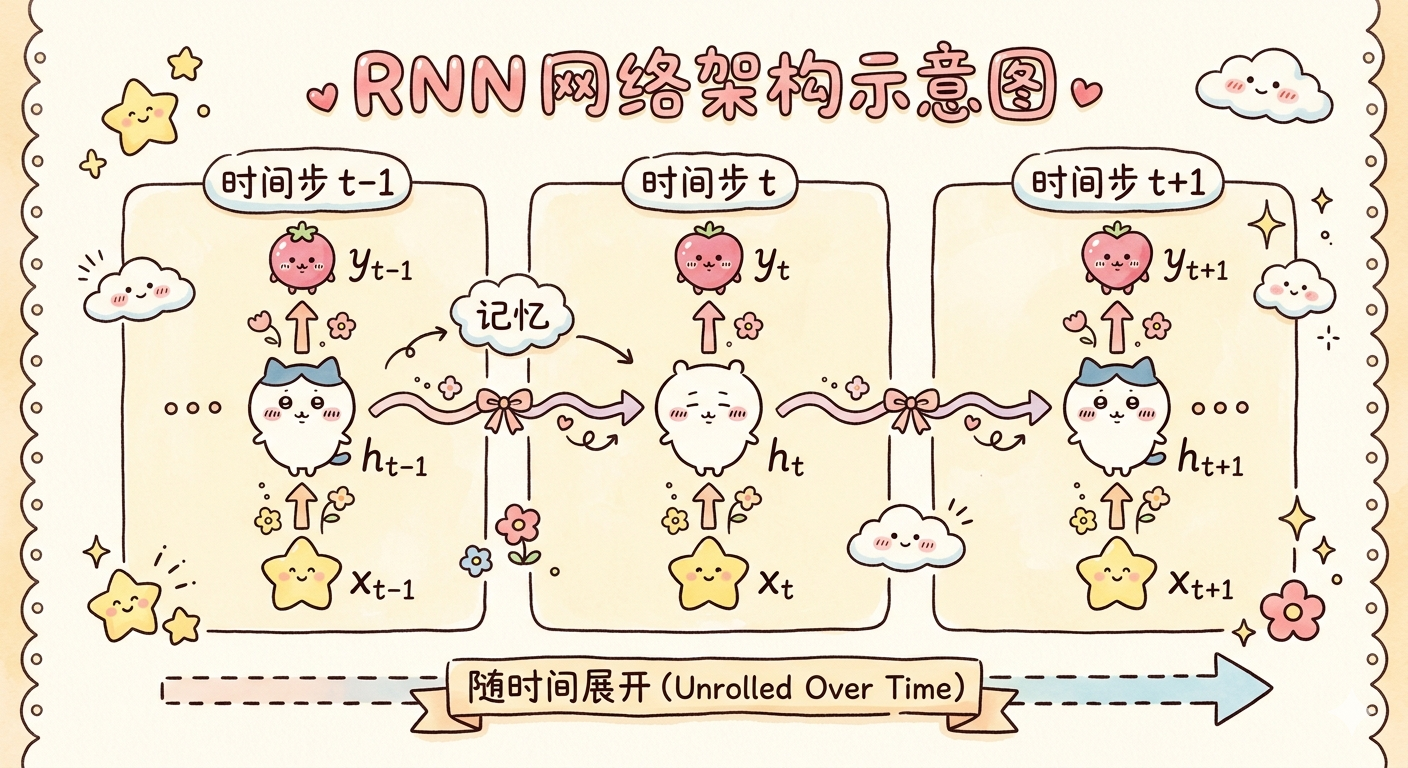

#### 案例：姓名分类器
- 需求：输入一个人名，模型帮我们判断其来自哪一个国家
- 数据说明：每一行第一个单词为人民，第二个单词为国家名，中间用tab分割
- 数据一共有20074条，18个国家


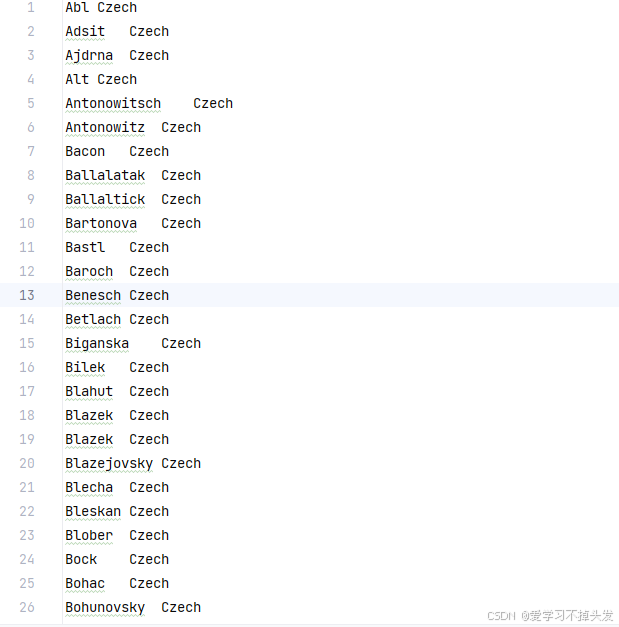

In [1]:
import glob
import string
import unicodedata
import random
import time
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)          # 57

def unicode_to_ascii(s):
    """将 Unicode 字符串转换为 ASCII，去除重音符号，仅保留 all_letters 中的字符"""
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn' and c in all_letters
    )

def read_names(filename):
    """读取文件，返回清洗后的姓名列表"""
    with open(filename, encoding='utf-8') as f:
        names = f.read().strip().split('\n')
    return [unicode_to_ascii(name) for name in names]

# 加载所有数据
all_filenames = glob.glob(r'.\Data\names\*.txt')  # 请根据实际路径修改
category_names = {}
all_categories = []

for filename in all_filenames:

    category = filename.split('\\')[-1].split('.')[0] # Windows 用这行
    all_categories.append(category)
    category_names[category] = read_names(filename)

n_categories = len(all_categories)
print(f'总类别数: {n_categories}, 字符集大小: {n_letters}')

总类别数: 18, 字符集大小: 57


In [6]:
def letter_to_index(letter):
    """返回字符在 all_letters 中的索引"""
    return all_letters.find(letter)

def name_to_tensor(name):
    """将姓名转换为形状为 (seq_len, 1, n_letters) 的 one-hot 张量"""
    tensor = torch.zeros(len(name), 1, n_letters)
    for i, letter in enumerate(name):
        idx = letter_to_index(letter)
        if idx != -1:
            tensor[i][0][idx] = 1
    return tensor

#### 手写RNN架构

In [ ]:
# 定义RNN模型（简单循环神经网络）
"""
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.input_size = input_size  # 输入维度（n_letters=57）
        self.hidden_size = hidden_size  # 隐藏层维度（自定义，如128）
        self.output_size = output_size  # 输出维度（n_categories=18）
        # 输入到隐藏层的线性层（输入为input+hidden的拼接）
        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        # 输入到输出层的线性层（输入为input+hidden的拼接）
        self.i2o = nn.Linear(input_size + hidden_size, output_size)

    def forward(self, input, hidden):
        # 拼接当前输入和上一时刻的隐藏状态
        combined = torch.cat((input, hidden), 1)
        hidden = self.i2h(combined)  # 更新隐藏状态
        output = self.i2o(combined)  # 计算当前输出
        return output, hidden

    def init_hidden(self):
        # 初始化隐藏状态（全0向量）
        return torch.zeros(1, self.hidden_size)
  """


#### pytorch官方架构

In [7]:
class RNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNNClassifier, self).__init__()
        self.hidden_size = hidden_size

        # 官方 RNN 层，batch_first=False 表示输入形状为 (seq_len, batch, input_size)
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=False)

        # 将 RNN 最后一个时间步的隐藏状态映射到输出类别
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, input_seq, hidden=None):
        """
        input_seq: (seq_len, batch, input_size)
        hidden:    (1, batch, hidden_size)，默认为 None（自动初始化为零）
        返回: output: (batch, output_size)
        """
        # RNN 前向传播
        # rnn_out: (seq_len, batch, hidden_size)
        # hidden:  (1, batch, hidden_size)
        rnn_out, hidden = self.rnn(input_seq, hidden)

        # 取最后一个时间步的输出进行分类
        last_out = rnn_out[-1]                # (batch, hidden_size)
        output = self.fc(last_out)            # (batch, output_size)
        return output

    def init_hidden(self, batch_size=1):
        """初始化隐藏状态为零张量"""
        return torch.zeros(1, batch_size, self.hidden_size)

In [8]:
def category_from_output(output):
    """从模型输出中获取预测类别名称和索引"""
    top_n, top_i = output.topk(1)       # top_i: (batch, 1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i

def random_training_pair():
    """随机生成一个训练样本（类别、姓名、标签张量、姓名张量）"""
    category = random.choice(all_categories)
    name = random.choice(category_names[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
    name_tensor = name_to_tensor(name)
    return category, name, category_tensor, name_tensor

def time_since(since):
    """格式化训练耗时"""
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return f'{m}m {s:.0f}s'

In [9]:
def train_step(category_tensor, name_tensor):
    """单步训练，返回损失值和模型输出"""
    optimizer.zero_grad()

    # 输入形状: (seq_len, batch=1, input_size)
    # 隐藏状态自动初始化为零
    output = model(name_tensor)          # (1, n_categories)

    loss = criterion(output, category_tensor)
    loss.backward()
    optimizer.step()

    return output, loss.item()

In [10]:
def predict(model, input_name, n_predictions=3):
    """对输入姓名进行 top‑k 预测并打印结果"""
    with torch.no_grad():
        name_tensor = name_to_tensor(input_name)
        output = model(name_tensor)      # (1, n_categories)

        topv, topi = output.topk(n_predictions, 1, True)
        print(f'\n> {input_name}')
        for i in range(n_predictions):
            value = topv[0][i].item()
            category_idx = topi[0][i].item()
            print(f'  ({value:.2f}) {all_categories[category_idx]}')

开始训练...
  5000 (5.0%) 0m 16s  loss: 2.6447  Riva / Vietnamese ✗ (Italian)
 10000 (10.0%) 0m 29s  loss: 2.0527  Blanchet / Irish ✗ (French)
 15000 (15.0%) 0m 46s  loss: 1.2168  De sauveterre / French ✓
 20000 (20.0%) 0m 58s  loss: 2.1605  Vuong / German ✗ (Vietnamese)
 25000 (25.0%) 1m 9s  loss: 3.4814  Nifterik / Czech ✗ (Dutch)
 30000 (30.0%) 1m 20s  loss: 0.1768  Luong / Vietnamese ✓
 35000 (35.0%) 1m 31s  loss: 1.7114  Schuyler / German ✗ (Dutch)
 40000 (40.0%) 1m 42s  loss: 0.2798  Koziol / Polish ✓
 45000 (45.0%) 1m 54s  loss: 2.7221  Zuraw / Portuguese ✗ (Polish)
 50000 (50.0%) 2m 5s  loss: 1.1240  Joe / Korean ✗ (Chinese)
 55000 (55.0%) 2m 16s  loss: 0.3193  Shalhoub / Arabic ✓
 60000 (60.0%) 2m 28s  loss: 1.0194  Ormston / English ✓
 65000 (65.0%) 2m 39s  loss: 0.3723  Lin / Chinese ✓
 70000 (70.0%) 2m 50s  loss: 0.6422  Lorenz / German ✓
 75000 (75.0%) 3m 2s  loss: 0.8677  Kopp / Czech ✓
 80000 (80.0%) 3m 13s  loss: 1.7626  Garrastazu / French ✗ (Spanish)
 85000 (85.0%) 3m 25s

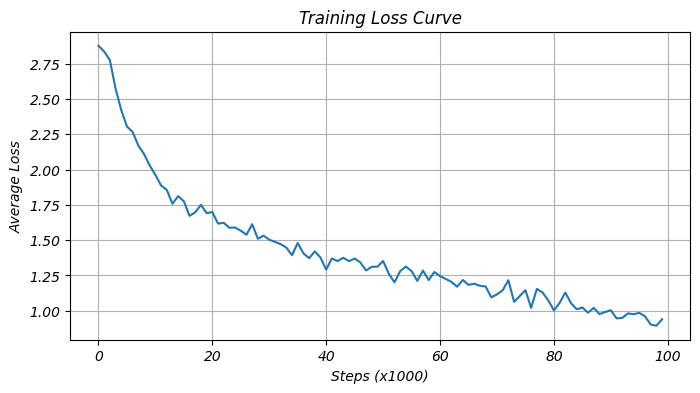


测试预测:

> Shang
  (8.56) Chinese
  (6.45) Korean
  (6.38) Vietnamese

> Jackson
  (8.97) Scottish
  (4.34) English
  (3.73) Russian

> ZHU
  (4.81) Korean
  (4.27) Chinese
  (3.13) Polish

模型已保存至 ./rnn_classifier.pth

> Wang
  (7.43) Chinese
  (6.97) Korean
  (4.00) Scottish

> Smith
  (6.28) Scottish
  (3.32) English
  (2.55) Czech

> Müller
  (4.67) Irish
  (4.51) German
  (4.24) Scottish


C:\Users\23017\AppData\Local\Temp\ipykernel_35912\3355422680.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(model_path))


In [11]:
if __name__ == '__main__':
    # 超参数
    HIDDEN_SIZE = 128
    LEARNING_RATE = 0.005
    N_EPOCHS = 100000
    PRINT_EVERY = 5000
    PLOT_EVERY = 1000

    # 初始化模型、损失函数、优化器
    model = RNNClassifier(n_letters, HIDDEN_SIZE, n_categories)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

    # 记录训练过程
    current_loss = 0.0
    all_losses = []
    start_time = time.time()

    print("开始训练...")
    for epoch in range(1, N_EPOCHS + 1):
        category, name, category_tensor, name_tensor = random_training_pair()
        output, loss = train_step(category_tensor, name_tensor)
        current_loss += loss

        # 打印训练状态
        if epoch % PRINT_EVERY == 0:
            guess, _ = category_from_output(output)
            correct = '✓' if guess == category else f'✗ ({category})'
            elapsed = time_since(start_time)
            print(f'{epoch:6d} ({epoch/N_EPOCHS*100:.1f}%) {elapsed}  loss: {loss:.4f}  {name} / {guess} {correct}')

        # 记录平均损失
        if epoch % PLOT_EVERY == 0:
            avg_loss = current_loss / PLOT_EVERY
            all_losses.append(avg_loss)
            current_loss = 0.0

    # 绘制损失曲线
    plt.figure(figsize=(8, 4))
    plt.plot(all_losses)
    plt.xlabel(f'Steps (x{PLOT_EVERY})')
    plt.ylabel('Average Loss')
    plt.title('Training Loss Curve')
    plt.grid(True)
    plt.show()

    print("\n测试预测:")
    predict(model, 'Shang')
    predict(model, 'Jackson')
    predict(model, 'ZHU')

    # 保存模型
    model_path = r'./rnn_classifier.pth'
    torch.save(model.state_dict(), model_path)
    print(f'\n模型已保存至 {model_path}')


    loaded_model = RNNClassifier(n_letters, HIDDEN_SIZE, n_categories)
    loaded_model.load_state_dict(torch.load(model_path))
    loaded_model.eval()
    predict(loaded_model, 'Wang')
    predict(loaded_model, 'Smith')
    predict(loaded_model, 'Müller')      # 测试非 ASCII 字符的处理